In [ ]:
!pip install torch transformers datasets peft trl pandas matplotlib requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 64.8 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 87.2 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 161.1 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 187.0 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 202.3 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 113.4 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 96.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 92.7 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 136.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 189.5 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.

In [ ]:
import multiprocessing
import os
import requests
import tarfile
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_dataset

from peft import LoraConfig
from transformers import AutoModelForCausalLM, AutoTokenizer,TrainingArguments, GPT2Tokenizer, set_seed, GenerationConfig
from trl import DPOConfig, DPOTrainer

/teamspace/studios/this_studio/.conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Load model
model = AutoModelForCausalLM.from_pretrained("gpt2")

# Load the reference model.
model_ref = AutoModelForCausalLM.from_pretrained("gpt2")

# Load tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# Define the end of sequence token
tokenizer.pad_token = tokenizer.eos_token
# Define the padding side as right to handle the overflow problem with FP16 training
tokenizer.padding_side = "right"

# Disable the use of the cache during the model's forward pass
model.config.use_cache = False

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 11396.10it/s]


In [ ]:
# Load the dataset 
dataset = load_dataset("argilla/ultrafeedback-binarized-preferences-cleaned")

Generating train split: 100%|██████████| 60917/60917 [00:01<00:00, 37221.29 examples/s]


In [ ]:
import multiprocessing
from datasets import load_dataset

# Reduce dataset volume by selecting the first 50 examples from each split
for key in dataset.keys():
    dataset[key] = dataset[key].select(range(50))


# Function to process data
def process(data_point):
    # Remove unwanted columns safely
    for col in ['source', 'chosen-rating', 'chosen-model', 'rejected-rating', 'rejected-model']:
        data_point.pop(col, None)  # Avoids errors if the column is missing

    # Extract the last response content
    data_point["chosen"] = data_point["chosen"][-1]["content"]
    data_point["rejected"] = data_point["rejected"][-1]["content"]

    return data_point

# Apply mapping to process al the rows
dataset = dataset.map(process, num_proc=multiprocessing.cpu_count(), load_from_cache_file=False,)

# Split train dataset: 90% for training, 10% for testing
ds_train_test = dataset["train"].train_test_split(test_size=0.1)

# Assign new splits
dataset["train"], dataset["test"] = ds_train_test["train"], ds_train_test["test"]

train_dataset = dataset["train"]
eval_dataset = dataset["test"]

train_dataset[0]

Map (num_proc=4): 100%|██████████| 50/50 [00:00<00:00, 109.69 examples/s]


{'prompt': 'Can you solve this language puzzle? Think about the impact of climate change in a certain region.\nWhat word becomes a palindrome when you add three letters to it? \nTo help you solve it, consider the average temperature increase in the region over the past few years. Use the following array of temperature values to calculate the average temperature increase per year: \nlet temperatures = [24, 26, 27, 29, 31, 33, 36, 35, 33, 30, 28, 25]; \nAs the temperature continues to rise, words are getting shorter and shorter. Can you figure out the word that fits this description?',
 'chosen': 'Sure! Let me first find the average temperature increase per year using the given temperature values.\n\nlet temperatures = [24, 26, 27, 29, 31, 33, 36, 35, 33, 30, 28, 25];\nlet totalYears = temperatures.length;\nlet temperatureSum = 0;\nfor(let i = 0; i < totalYears; i++)\n{ \n   temperatureSum += temperatures[i]; \n}\nlet avgTemperature = Math.round(temperatureSum / totalYears);\n\nThe avera

In [ ]:
from peft import LoraConfig

# Configure LoRA (Low-Rank Adaptation) for efficient fine-tuning
peft_config = LoraConfig(
        # Rank parameter defining the size of the LoRA update matrices
        r=4,
        # Layers where LoRA is applied (projection and attention layers)
        target_modules=['c_proj', 'c_attn'],
        # Specifies the task type (Causal Language Modeling)
        task_type="CAUSAL_LM",
        # Scaling factor that controls the impact of LoRA weights
        lora_alpha=8,
        # Dropout applied to LoRA layers to prevent overfitting
        lora_dropout=0.1,
        # Bias configuration (no additional bias is applied)
        bias="none",
)

In [ ]:
from trl import DPOConfig

# Configure Direct Preference Optimization (DPO) training parameters
training_args = DPOConfig(
    # Temperature parameter controlling the sharpness of preference modeling in DPO loss
    # Typically set in the range of 0.1 to 0.5 for stable optimization
    beta=0.1,
    # Directory to save model checkpoints and outputs
    output_dir="dpo",
    # Number of times the entire dataset is passed through during training
    num_train_epochs=1,
    # Batch size for training per device (smaller values prevent memory issues)
    per_device_train_batch_size=1,
    # Batch size for evaluation per device
    per_device_eval_batch_size=1,
    # Ensures dataset columns not required by the model are not removed
    remove_unused_columns=False,
    # Log training progress every `logging_steps` steps
    logging_steps=10,
    # Number of steps to accumulate gradients before performing an optimizer update
    gradient_accumulation_steps=1,
    # Learning rate for the optimizer (affects model weight updates)
    learning_rate=1e-4,
    # Defines when evaluation occurs (e.g., after each epoch)
    eval_strategy="epoch",
    # Number of warmup steps before reaching the full learning rate
    warmup_steps=2,
    # Whether to use 16-bit floating point precision (reduces memory usage)
    fp16=False,
    # Save model checkpoints every `save_steps` steps
    save_steps=500,
    # Backend for tracking training progress ('none' disables logging, alternatives include 'wandb' or 'tensorboard')
    report_to='none',           # Maximum input prompt length
    max_length=512,                    # Maximum sequence length (prompt + response)
)

In [ ]:
# Set the padding token to be the same as the EOS (end-of-sequence) token
tokenizer.pad_token = tokenizer.eos_token

# Initialize the Direct Preference Optimization (DPO) Trainer
trainer = DPOTrainer(
        model=model,                    # The model to be fine-tuned
        ref_model=None,                  # No reference model needed with LoRA
        args=training_args,               # DPOConfig containing all hyperparameters, including beta
        train_dataset=train_dataset,      # Dataset for training
        eval_dataset=eval_dataset,        # Dataset for evaluation
        processing_class=tokenizer,              # Tokenizer to process input/output text
        peft_config=peft_config,          # LoRA configuration for efficient fine-tuning      
)

# Start the training process
trainer.train()

/teamspace/studios/this_studio/.conda/lib/python3.12/site-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(
Adding EOS to train dataset: 100%|██████████| 45/45 [00:00<00:00, 5067.62 examples/s]


Tokenizing train dataset:   0%|          | 0/45 [00:00<?, ? examples/s][transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1295 > 1024). Running this sequence through the model will result in indexing errors
[RANK 0] Mismatch between tokenized prompt and the start of tokenized prompt+chosen. This may be due to unexpected tokenizer behavior, whitespace issues, or special token handling. Verify that the tokenizer is processing text consistently.
Tokenizing eval dataset: 100%|██████████| 5/5 [00:00<00:00, 199.68 examples/s]
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


Epoch,Training Loss,Validation Loss
1,0.743237,0.651082


TrainOutput(global_step=45, training_loss=0.7315970579783122, metrics={'train_runtime': 24.0521, 'train_samples_per_second': 1.871, 'train_steps_per_second': 1.871, 'total_flos': 19704688054272.0, 'train_loss': 0.7315970579783122})

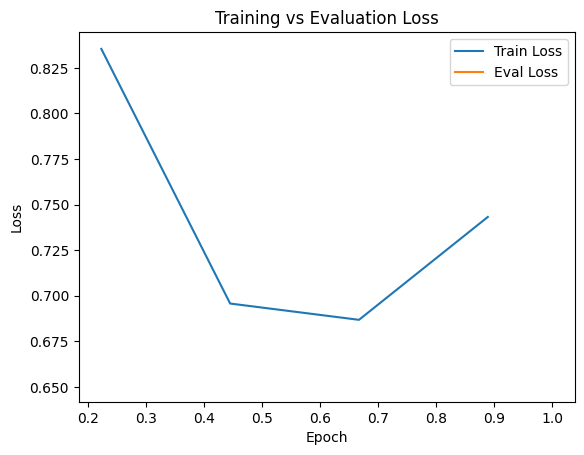

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert log history to a DataFrame
log = pd.DataFrame(trainer.state.log_history)

# Filter training and evaluation loss entries
train_log = log.dropna(subset=['loss'])
eval_log = log.dropna(subset=['eval_loss'])

# Plot training and evaluation losses
plt.plot(train_log["epoch"], train_log["loss"], label="Train Loss")
plt.plot(eval_log["epoch"], eval_log["eval_loss"], label="Eval Loss")

# Add legend and show plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Evaluation Loss")
plt.show()

In [ ]:
# Load again the tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

In [ ]:
# Set a seed for reproducibility
set_seed(31)

# Define parameters for response generation
generation_config = GenerationConfig(
    do_sample=True,
    top_k=1,
    temperature=0.1,
    max_new_tokens=25,
    pad_token_id=tokenizer.eos_token_id
)

PROMPT = "Is eating animals cruel?"

# Move inputs to same device as model
device = model.device
inputs = tokenizer(PROMPT, return_tensors='pt').to(device)

# Generate response from DPO model
outputs = model.generate(**inputs, generation_config=generation_config)

print("DPO response:", tokenizer.decode(outputs[0], skip_special_tokens=True))

# Load GPT2
gpt2_model = AutoModelForCausalLM.from_pretrained("gpt2").to(device)

# Generate response
outputs = gpt2_model.generate(**inputs, generation_config=generation_config)

print("GPT2 response:", tokenizer.decode(outputs[0], skip_special_tokens=True))

DPO response: Is eating animals cruel?

The answer is yes.

The Humane Society of the United States (HSUS) has been working with the


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 4656.39it/s]


GPT2 response: Is eating animals cruel?

The answer is yes.

The Humane Society of the United States (HSUS) has been working with the
